In [8]:
from tqdm import tqdm

import torch
from torch import nn
import torch.nn.functional as F
from torch.optim import Adam, SGD
from torch.optim.lr_scheduler import StepLR
from torch.utils.data import DataLoader, Subset

from torchvision.datasets import CIFAR10
from torchvision import transforms

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

# Чтение и подготовка данных

Для начала обозначим преобразования для данных. Нам нужно превратить картинки в тензоры, для этого есть ToTensor(), а также нормализовать данные от 0 до 1 (значения от 0 до 255 имеют большой скейл и нейронки хуже будут с ними работать)

In [9]:
transform = transforms.Compose([
    transforms.Resize((32, 32)),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.247, 0.243, 0.261))
])

Теперь создадим готовый датасет из PyTorch и загрузчик данных для создания батчей

In [10]:
train_dataset = CIFAR10(root='cifar10', train=True, download=True, transform=transform)

In [11]:
print(train_dataset[0][0].shape)

torch.Size([3, 32, 32])


Давайте посмотрим, что возвращает датасет и даталоадер

In [12]:
train_loader = DataLoader(dataset=train_dataset, batch_size=8, shuffle=True)

Посмотрим как выглядит семпл

In [13]:
batch = next(iter(train_loader))
batch[0].shape

torch.Size([8, 3, 32, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9100897..2.1206896].


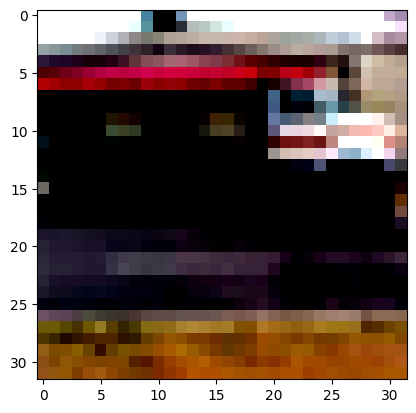

In [14]:
sample_img = batch[0].numpy()[1].transpose(1, 2, 0)

plt.imshow(sample_img)

# Простая CNN

Давайте сделаем простую CNN. Сделаем ее с 3 свертками и пулингом

In [15]:
class BasicCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(1024, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = self.pool(F.relu(self.conv3(x)))

        x = x.view(-1, 64 * 4 * 4)

        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

Посмотрим, что она выдаст

In [16]:
cnn = BasicCNN()

out = cnn(batch[0])
print(out.shape)

torch.Size([8, 10])


# Напишем код для тренировки

Тренировка и тестирование будет реализованно в классе Trainer

Обозначим конфиг, где будут параметры для тренировки

In [22]:
config = {
    'num_epochs': 5,
    'lr': 0.01,
    'batch_size': 128,
    'test_size': 0.2
}

In [28]:
class Trainer:
    def __init__(self, config, model, transform=None): 
        self.config = config
        self.transform = transform
        self.device = 'cuda' if torch.cuda.is_available() else 'cpu'
        
        self.model = model.to(self.device)
        
        self.optimizer = Adam(self.model.parameters(), lr=self.config['lr'])
        self.scheduler = StepLR(self.optimizer, step_size=5, gamma=0.1)
        self.loss_function = nn.CrossEntropyLoss()
        self.train_losses = []
        self.train_accs = []
        self.val_losses = []
        self.val_accs = []
        
        self.setup_dataloaders()
    
    def run(self):
        for epoch in range(self.config['num_epochs']):
            train_loss, train_acc = self.train_step()
            val_loss, val_acc = self.val_step()
            
            self.train_losses.append(train_loss)
            self.train_accs.append(train_acc)
            self.val_losses.append(val_loss)
            self.val_accs.append(val_acc)
            
            print(f'Epoch {epoch + 1} / {self.config['num_epochs']} | '
                  f'Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | '
                  f'Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}%')
        
        test_loss, test_acc = self.test_step()
        print(f'Test loss {test_loss:.4f}, test acc {test_acc:.2f}%')
        return test_acc

    def setup_dataloaders(self):
        train_dataset_full = CIFAR10(root='cifar10', train=True, download=True, transform=self.transform)
        test_dataset = CIFAR10(root='cifar10', train=False, download=True, transform=self.transform)

        train_indices, val_indices = train_test_split(list(range(len(train_dataset_full))), test_size=self.config['test_size'], random_state=42, shuffle=True)
        train_dataset = Subset(train_dataset_full, train_indices)
        val_dataset = Subset(train_dataset_full, val_indices)

        self.train_loader = DataLoader(dataset=train_dataset, batch_size=self.config['batch_size'], shuffle=True)
        self.val_loader = DataLoader(dataset=val_dataset, batch_size=self.config['batch_size'], shuffle=False)
        self.test_loader = DataLoader(dataset=test_dataset, batch_size=self.config['batch_size'], shuffle=False)

    def train_step(self):
        self.model.train()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.train_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            self.optimizer.zero_grad()

            outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            loss.backward()

            self.optimizer.step()

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        self.scheduler.step()

        total_loss = total_loss / len(self.train_loader)
        train_acc = correct / total_samples * 100

        return total_loss, train_acc

    def val_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.val_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.val_loader)
        val_acc = correct / total_samples * 100

        return total_loss, val_acc

    def test_step(self):
        self.model.eval()

        total_loss = 0.0
        correct = 0
        total_samples = 0

        for images, labels in tqdm(self.test_loader):
            images, labels = images.to(self.device), labels.to(self.device)

            with torch.no_grad():
                outputs = self.model(images)
            loss = self.loss_function(outputs, labels)

            total_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)
            correct += (preds == labels).sum().item()
            total_samples += labels.size(0)

        total_loss = total_loss / len(self.test_loader)
        test_acc = correct / total_samples * 100

        return total_loss, test_acc

In [27]:
print()
print("Training Basic CNN")
print()
trainer_cnn = Trainer(config, basic_cnn, transform=transform)
test_acc_cnn = trainer_cnn.run()

cnn_history = {
    'train_accs': trainer_cnn.train_accs,
    'val_accs': trainer_cnn.val_accs,
    'test_acc': test_acc_cnn
}


Training Basic CNN

Using device: cpu
GPU name: No GPU


100%|█| 313/313 [00:15<00:0
100%|█| 79/79 [00:02<00:00,


Epoch 1 / 5 | Train Loss: 1.6653 | Train Acc: 38.64% | Val Loss: 1.4667 | Val Acc: 46.62%


100%|█| 313/313 [00:15<00:0
100%|█| 79/79 [00:02<00:00,


Epoch 2 / 5 | Train Loss: 1.3784 | Train Acc: 50.40% | Val Loss: 1.3507 | Val Acc: 52.07%


...

Epoch 4 / 5 | Train Loss: 1.2540 | Train Acc: 55.34% | Val Loss: 1.2909 | Val Acc: 54.52%


100%|█| 313/313 [00:16<00:0
100%|█| 79/79 [00:02<00:00,


Epoch 5 / 5 | Train Loss: 1.2115 | Train Acc: 56.69% | Val Loss: 1.2806 | Val Acc: 54.61%


100%|█| 79/79 [00:02<00:00,

Test loss 1.2890, test acc 54.67%


In [13]:
trainer.run()

100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:02<00:00, 27.45it/s]


Epoch 1 / 10 1.6577296976845104 1.5195822444143174 44.98


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:02<00:00, 26.54it/s]


Epoch 2 / 10 1.4020169878158326 1.4273539962647837 48.59


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:02<00:00, 27.14it/s]


...

Epoch 9 / 10 0.9830144281966237 1.2005634956722018 58.15


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:02<00:00, 27.11it/s]


Epoch 10 / 10 0.9679140867516637 1.20848517327369 57.31


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:02<00:00, 27.62it/s]

Test loss 1.2232846429076376, test acc 57.67


# ResNet-18

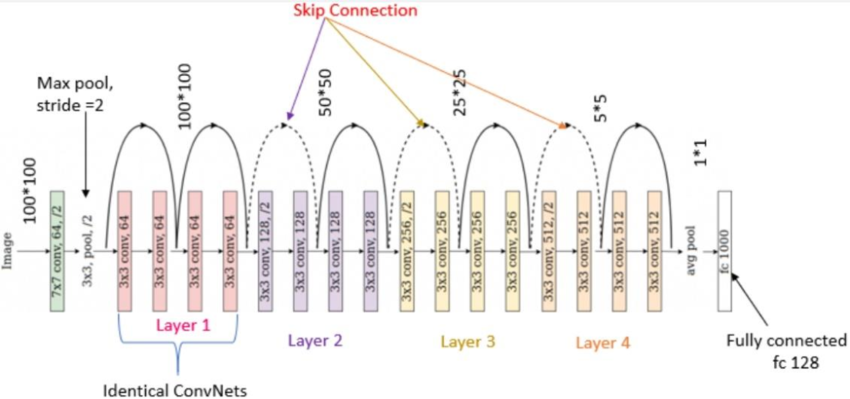

In [31]:
import torch.nn as nn
import torch.nn.functional as F

class ResNetBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample

    def forward(self, x):
        identity = x
        if self.downsample is not None:
            identity = self.downsample(identity)
        out = self.conv1(x)
        out = self.bn1(out)
        out = F.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = F.relu(out)
        return out

class ResNet18(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.in_channels = 64
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3)
        self.bn1 = nn.BatchNorm2d(64)
        self.max_poool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self.make_layer(64, blocks=2, stride=1)
        self.layer2 = self.make_layer(128, blocks=2, stride=2)
        self.layer3 = self.make_layer(256, blocks=2, stride=2)
        self.layer4 = self.make_layer(512, blocks=2, stride=2)
        self.avg_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)

    def make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, stride=stride),
                nn.BatchNorm2d(out_channels)
            )  
        layers = []
        layers.append(ResNetBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels  
        for _ in range(1, blocks):
            layers.append(ResNetBlock(self.in_channels, out_channels))
        return nn.Sequential(*layers)

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = F.relu(x)
        x = self.max_poool(x)   
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x) 
        x = self.avg_pool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)  
        return x


$H_{out}=\frac{H_{in}+2P-D(K-1)-1}{S}+1$ \\
$W_{out}=\frac{W_{in}+2P-D(K-1)-1}{S}+1$

In [29]:
basic_cnn = BasicCNN()
print("Training Basic CNN")
print(f"Basic CNN parameters: {sum(p.numel() for p in basic_cnn.parameters()):,}")
print()
trainer_cnn = Trainer(config, basic_cnn, transform=transform)
test_acc_cnn = trainer_cnn.run()
cnn_history = {
    'train_accs': trainer_cnn.train_accs,
    'val_accs': trainer_cnn.val_accs,
    'test_acc': test_acc_cnn
}

print()
resnet18 = ResNet18(num_classes=10)
print("Training ResNet18")
print(f"ResNet18 parameters: {sum(p.numel() for p in resnet18.parameters()):,}")
print()
trainer_resnet = Trainer(config, resnet18, transform=transform)
test_acc_resnet = trainer_resnet.run()
resnet_history = {
    'train_accs': trainer_resnet.train_accs,
    'val_accs': trainer_resnet.val_accs,
    'test_acc': test_acc_resnet
}

Training Basic CNN
Basic CNN parameters: 156,074



100%|█| 313/313 [00:15<00:0
100%|█| 79/79 [00:02<00:00,


Epoch 1 / 5 | Train Loss: 1.5899 | Train Acc: 41.42% | Val Loss: 1.3346 | Val Acc: 51.27%


100%|█| 313/313 [00:15<00:0
100%|█| 79/79 [00:02<00:00,


Epoch 2 / 5 | Train Loss: 1.2920 | Train Acc: 53.97% | Val Loss: 1.2696 | Val Acc: 54.72%


...

Epoch 4 / 5 | Train Loss: 0.8876 | Train Acc: 68.51% | Val Loss: 0.8839 | Val Acc: 68.93%


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:06<00:00, 11.71it/s]


Epoch 5 / 5 | Train Loss: 0.7597 | Train Acc: 73.50% | Val Loss: 0.8825 | Val Acc: 69.68%


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 79/79 [00:06<00:00, 11.63it/s]

Test loss 0.8950, test acc 69.28%


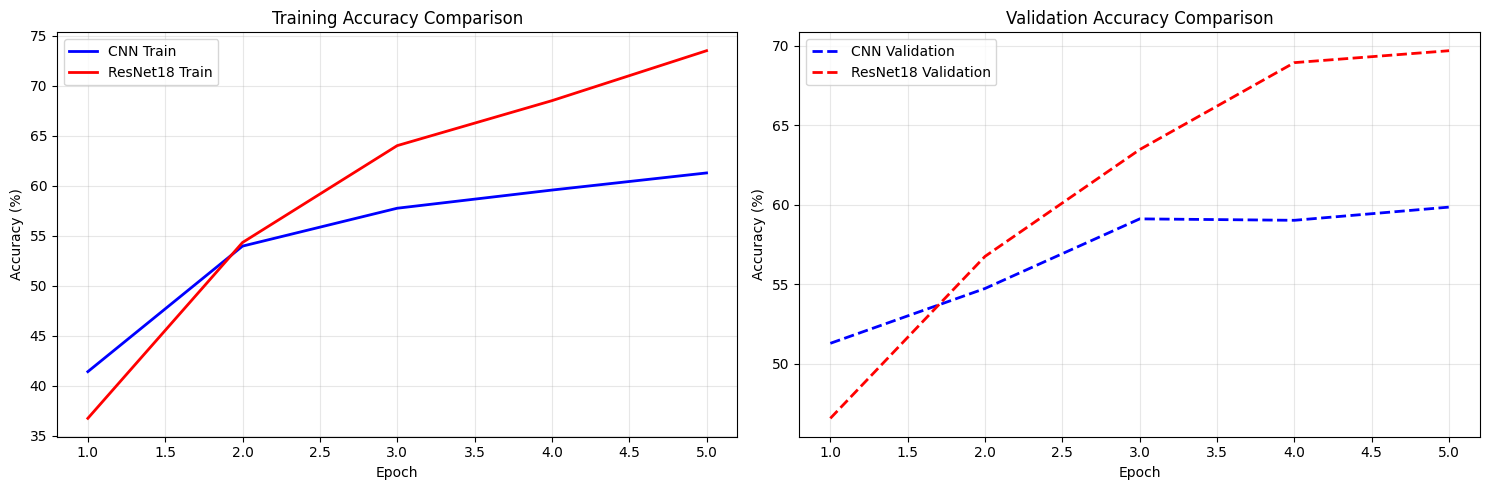

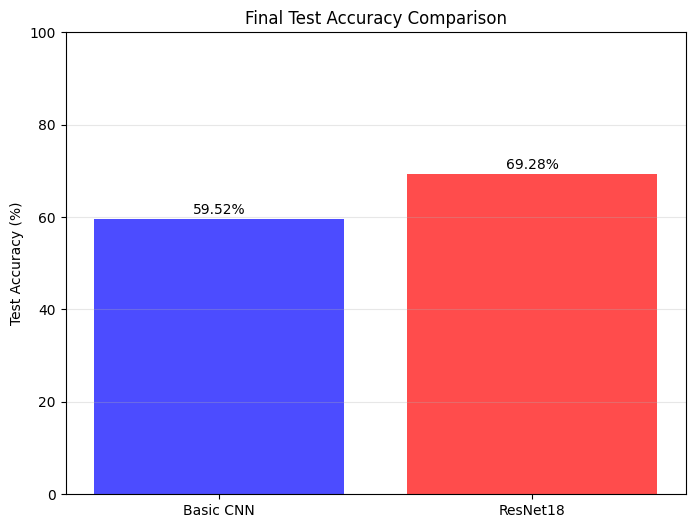

In [30]:
import matplotlib.pyplot as plt

epochs = range(1, config['num_epochs'] + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(epochs, cnn_history['train_accs'], 'b-', label='CNN Train', linewidth=2)
ax1.plot(epochs, resnet_history['train_accs'], 'r-', label='ResNet18 Train', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy (%)')
ax1.set_title('Training Accuracy Comparison')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs, cnn_history['val_accs'], 'b--', label='CNN Validation', linewidth=2)
ax2.plot(epochs, resnet_history['val_accs'], 'r--', label='ResNet18 Validation', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Validation Accuracy Comparison')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
models = ['Basic CNN', 'ResNet18']
test_accs = [cnn_history['test_acc'], resnet_history['test_acc']]
colors = ['blue', 'red']
bars = plt.bar(models, test_accs, color=colors, alpha=0.7)
plt.ylabel('Test Accuracy (%)')
plt.title('Final Test Accuracy Comparison')

for bar, acc in zip(bars, test_accs):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
             f'{acc:.2f}%', ha='center', va='bottom')

plt.ylim(0, 100)
plt.grid(True, alpha=0.3, axis='y')
plt.show()